# CFRM 521/421 Machine Learning for Finance
## Course Project Template

**Project Title:** Volatility Prediction of Microsoft Using Machine Learning

**Group Members:**  
- Jenny Fu (email: jennyfu1@uw.edu, Algorithm: Support Vector Regression)
- Emma Xu (email: zihanxu@uw.edu, Algorithm: Gradient Boosing)  
- Shawn Wen (email: ___, Algorithm: Neural Network with MLP)  
- Summer Zhu (email: ___, Algorithm: Random Forest)   

**Date:**

<span style="color:red">
**Please remove the bullet points in each section as you proceed and feel free to adjust the structure and contents as needed.
</span>

# 1. Introduction

## 1.1 Problem Statement
- What is the goal of your project?
- Why is this problem important in finance?
- What financial decision, prediction, or classification task are you studying?

## 1.2 Related Literature
- Briefly summarize relevant papers or prior work.
- Explain how your project relates to existing studies.
- Cite all sources properly.

## 1.3 Contribution
- What does your project add beyond existing work?
- Is your contribution empirical comparison, replication with extensions, new data, or a new application?


# 2. Data Description

## 2.1 Data Source
- Describe the original source of the data.
- Include links, API names, or repository names if relevant.

## 2.2 Data Structure
- What does each row represent?
- What is the sampling frequency?
- How many observations are there?
- What time period does the data cover?

## 2.3 Target Variable
- Define the response variable clearly.

## 2.4 Features
- List and briefly describe the predictors.
- Give a few examples.

## 2.5 Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)


In [3]:
import yfinance as yf

# Load data
tickers = ['MSFT', 'SPY', 'QQQ', 'XLK', '^VIX']

data = yf.download(
    tickers,
    start='2016-01-01',
    end='2026-01-01',
    auto_adjust=True
)

data.head()


[*********************100%***********************]  5 of 5 completed


Price           Close                                                \
Ticker           MSFT         QQQ         SPY        XLK       ^VIX   
Date                                                                  
2016-01-04  47.770718  101.717285  169.908203  18.860453  20.700001   
2016-01-05  47.988659  101.540787  170.195526  18.811369  19.340000   
2016-01-06  47.116936  100.565453  168.048630  18.579359  20.590000   
2016-01-07  45.478073   97.416351  164.016922  18.030537  24.990000   
2016-01-08  45.617550   96.617516  162.216537  17.887758  27.010000   

Price            High                                                ...  \
Ticker           MSFT         QQQ         SPY        XLK       ^VIX  ...   
Date                                                                 ...   
2016-01-04  47.770718  101.810176  169.916651  18.864914  23.360001  ...   
2016-01-05  48.285047  102.348954  170.651945  18.963074  21.059999  ...   
2016-01-06  47.422043  101.150673  169.096707  18.704292  21.860001  ...   
2016-01-07  46.628758   99.664348  166.882252  18.436569  25.860001  ...   
2016-01-08  46.445689   98.735464  165.538298  18.249173  27.080000  ...   

Price            Open                                                  Volume  \
Ticker           MSFT         QQQ         SPY        XLK       ^VIX      MSFT   
Date                                                                            
2016-01-04  47.352288  101.670836  169.460232  18.766753  22.480000  53778000   
2016-01-05  47.884052  102.218905  170.229330  18.918455  20.750000  34079700   
2016-01-06  47.352303   99.775868  167.642910  18.534741  21.670000  39518900   
2016-01-07  45.940091   98.419585  165.098816  18.200089  23.219999  56564900   
2016-01-08  45.652417   98.122370  164.980443  18.186705  22.959999  48754000   

Price                                           
Ticker           QQQ        SPY       XLK ^VIX  
Date                                            
2016-01-04  50807600  222353500  43277200    0  
2016-01-05  38795200  110845800  32134400    0  
2016-01-06  41891100  152112600  27716800    0  
2016-01-07  61386300  213436100  33681400    0  
2016-01-08  69344000  209817200  38466200    0  

[5 rows x 25 columns]

In [4]:
# Flatten MultiIndex columns
data.columns = [f"{ticker}_{price}" for price, ticker in data.columns]

# Rename ^VIX to VIX for easier use
data = data.rename(columns=lambda x: x.replace('^VIX', 'VIX'))

# Check column names
data.columns

# Create a working dataframe
df = data.copy()

# =========================
# 1. Daily returns
# =========================

df['MSFT_return_1d'] = df['MSFT_Close'].pct_change()
df['SPY_return_1d'] = df['SPY_Close'].pct_change()
df['QQQ_return_1d'] = df['QQQ_Close'].pct_change()
df['XLK_return_1d'] = df['XLK_Close'].pct_change()


# =========================
# 2. MSFT lag returns
# =========================

df['MSFT_return_lag1'] = df['MSFT_return_1d'].shift(1)
df['MSFT_return_lag3'] = df['MSFT_return_1d'].shift(3)
df['MSFT_return_lag5'] = df['MSFT_return_1d'].shift(5)
df['MSFT_return_lag10'] = df['MSFT_return_1d'].shift(10)
df['MSFT_return_lag15'] = df['MSFT_return_1d'].shift(15)
df['MSFT_return_lag21'] = df['MSFT_return_1d'].shift(21)


# =========================
# 3. MSFT rolling volatility
# =========================

df['MSFT_rolling_vol_5'] = df['MSFT_return_1d'].rolling(window=5).std()
df['MSFT_rolling_vol_21'] = df['MSFT_return_1d'].rolling(window=21).std()


# =========================
# 4. MSFT log volume
# =========================

df['MSFT_log_volume'] = np.log(df['MSFT_Volume'])


# =========================
# 5. SPY market-wide features
# =========================

df['SPY_return_lag1'] = df['SPY_return_1d'].shift(1)
df['SPY_rolling_vol_5'] = df['SPY_return_1d'].rolling(window=5).std()
df['SPY_rolling_vol_21'] = df['SPY_return_1d'].rolling(window=21).std()


# =========================
# 6. QQQ technology market features
# =========================

df['QQQ_rolling_vol_21'] = df['QQQ_return_1d'].rolling(window=21).std()


# =========================
# 7. VIX features
# =========================

df['VIX_level'] = df['VIX_Close']
df['VIX_change'] = df['VIX_Close'].pct_change()
df['VIX_lag1'] = df['VIX_Close'].shift(1)


# =========================
# 8. XLK sector ETF features
# =========================

df['XLK_rolling_vol_5'] = df['XLK_return_1d'].rolling(window=5).std()
df['XLK_rolling_vol_21'] = df['XLK_return_1d'].rolling(window=21).std()


# =========================
# 9. Relative performance features
# =========================

df['MSFT_minus_XLK_return'] = df['MSFT_return_1d'] - df['XLK_return_1d']
df['MSFT_minus_SPY_return'] = df['MSFT_return_1d'] - df['SPY_return_1d']


# Check result
df.head()

# =========================
# 10. Target variables
# =========================

# Daily prediction target
df['target_volatility_1d'] = df['MSFT_return_1d'].shift(-1).abs()

# Weekly prediction target
df['target_volatility_5d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=5)
    .std()
    .shift(-4)
)

# Monthly prediction target
df['target_volatility_21d'] = (
    df['MSFT_return_1d']
    .shift(-1)
    .rolling(window=21)
    .std()
    .shift(-20)
)

In [5]:
# =========================
# 11. Final model dataset
# =========================

feature_cols = [
    'MSFT_return_1d',
    'MSFT_return_lag1',
    'MSFT_return_lag3',
    'MSFT_return_lag5',
    'MSFT_return_lag10',
    'MSFT_return_lag15',
    'MSFT_return_lag21',
    'MSFT_rolling_vol_5',
    'MSFT_rolling_vol_21',
    'MSFT_log_volume',
    
    'SPY_return_1d',
    'SPY_return_lag1',
    'SPY_rolling_vol_5',
    'SPY_rolling_vol_21',
    
    'QQQ_return_1d',
    'QQQ_rolling_vol_21',
    
    'VIX_level',
    'VIX_change',
    'VIX_lag1',
    
    'XLK_return_1d',
    'XLK_rolling_vol_5',
    'XLK_rolling_vol_21',
    
    'MSFT_minus_XLK_return',
    'MSFT_minus_SPY_return'
]

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

# Dataset before dropna
model_data_before_dropna = df[feature_cols + target_cols].copy()

# Total number of NaN values
total_na = model_data_before_dropna.isna().sum().sum()
print("Shape before dropna:", model_data_before_dropna.shape)
print("Total NaN values before dropna:", total_na)

# NaN values by column
na_by_column = model_data_before_dropna.isna().sum()
na_by_column[na_by_column > 0]
print("NaN values by column:", na_by_column[na_by_column > 0])

# Number of rows with at least one NaN
rows_with_na = model_data_before_dropna.isna().any(axis=1).sum()
print("Rows with at least one NaN:", rows_with_na)

# Keep only features and targets, then drop missing values
model_data = df[feature_cols + target_cols].dropna()

print("Final model_data shape:", model_data.shape)

model_data.head()

Shape before dropna: (2514, 27)
Total NaN values before dropna: 197
NaN values by column: MSFT_return_1d            1
MSFT_return_lag1          2
MSFT_return_lag3          4
MSFT_return_lag5          6
MSFT_return_lag10        11
MSFT_return_lag15        16
MSFT_return_lag21        22
MSFT_rolling_vol_5        5
MSFT_rolling_vol_21      21
SPY_return_1d             1
SPY_return_lag1           2
SPY_rolling_vol_5         5
SPY_rolling_vol_21       21
QQQ_return_1d             1
QQQ_rolling_vol_21       21
VIX_change                1
VIX_lag1                  1
XLK_return_1d             1
XLK_rolling_vol_5         5
XLK_rolling_vol_21       21
MSFT_minus_XLK_return     1
MSFT_minus_SPY_return     1
target_volatility_1d      1
target_volatility_5d      5
target_volatility_21d    21
dtype: int64
Rows with at least one NaN: 43
Final model_data shape: (2471, 27)


,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,VIX_change,VIX_lag1,XLK_return_1d,XLK_rolling_vol_5,XLK_rolling_vol_21,MSFT_minus_XLK_return,MSFT_minus_SPY_return,target_volatility_1d,target_volatility_5d,target_volatility_21d
Date,,,,,,,,,,,,,,,,,,,,,
2016-02-04,-0.003067,-0.015849,-0.006898,0.016400,-0.006104,-0.021599,0.004562,0.034177,0.023676,17.665384,...,0.008776,21.650000,0.000985,0.017823,0.017475,-0.004052,-0.004636,0.035385,0.017031,0.017589
2016-02-05,-0.035385,-0.003067,-0.031255,0.058202,0.035856,0.028466,-0.018165,0.014384,0.024531,17.942790,...,0.070513,21.840000,-0.028051,0.013787,0.018276,-0.007334,-0.016335,0.014952,0.011859,0.015833
2016-02-08,-0.014952,-0.035385,-0.015849,-0.006898,-0.009562,-0.039917,-0.034783,0.013160,0.023622,17.897960,...,0.112062,23.379999,-0.014430,0.012069,0.017430,-0.000522,-0.001491,0.002631,0.009653,0.015987
2016-02-09,-0.002631,-0.014952,-0.003067,-0.031255,0.007337,-0.008433,0.003067,0.013320,0.023590,17.660122,...,0.020769,26.000000,-0.004624,0.011943,0.017385,0.001993,-0.002684,0.008725,0.010121,0.016449
2016-02-10,0.008725,-0.002631,-0.035385,-0.015849,-0.018210,0.004549,-0.000573,0.016737,0.023716,17.459314,...,-0.009420,26.540001,0.001548,0.012475,0.017305,0.007177,0.009588,0.000402,0.013073,0.016803


In [6]:
# =========================
# 14. Time-series train / validation / test split
# =========================

# Make sure data is sorted by date
model_data = model_data.sort_index()

# Split indices
n = len(model_data)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

# Split data
train_data = model_data.iloc[:train_end]
valid_data = model_data.iloc[train_end:valid_end]
test_data = model_data.iloc[valid_end:]

print("Total observations:", n)
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)

print("Train period:", train_data.index.min(), "to", train_data.index.max())
print("Validation period:", valid_data.index.min(), "to", valid_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())

# =========================
# 15. Define X variables
# =========================

X_train = train_data[feature_cols]
X_valid = valid_data[feature_cols]
X_test = test_data[feature_cols]


# =========================
# 16. Define y variables for each prediction horizon
# =========================

# Daily target
y_train_1d = train_data['target_volatility_1d']
y_valid_1d = valid_data['target_volatility_1d']
y_test_1d = test_data['target_volatility_1d']

# Weekly target
y_train_5d = train_data['target_volatility_5d']
y_valid_5d = valid_data['target_volatility_5d']
y_test_5d = test_data['target_volatility_5d']

# Monthly target
y_train_21d = train_data['target_volatility_21d']
y_valid_21d = valid_data['target_volatility_21d']
y_test_21d = test_data['target_volatility_21d']

Total observations: 2471
Train shape: (1729, 27)
Validation shape: (371, 27)
Test shape: (371, 27)
Train period: 2016-02-04 00:00:00 to 2022-12-14 00:00:00
Validation period: 2022-12-15 00:00:00 to 2024-06-07 00:00:00
Test period: 2024-06-10 00:00:00 to 2025-12-01 00:00:00


In [7]:
# =========================
# 17. Standardize X variables
# =========================

from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_train)

# Transform train, validation, and test using the same scaler
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=feature_cols
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    index=X_valid.index,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=feature_cols
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_valid_scaled shape:", X_valid_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1729, 24)
X_valid_scaled shape: (371, 24)
X_test_scaled shape: (371, 24)


# 3. Exploratory Data Analysis

- Summarize the data.
- Visualize key variables.
- Examine the target variable.
- Discuss stylized facts or empirical patterns relevant to the financial problem.


In [8]:
# Basic summary statistics
# df.describe()

# =========================
# 3.1 Basic summary statistics
# =========================

print("Dataset shape:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

model_data.describe()

Dataset shape: (2471, 27)
Start date: 2016-02-04 00:00:00
End date: 2025-12-01 00:00:00


,MSFT_return_1d,MSFT_return_lag1,MSFT_return_lag3,MSFT_return_lag5,MSFT_return_lag10,MSFT_return_lag15,MSFT_return_lag21,MSFT_rolling_vol_5,MSFT_rolling_vol_21,MSFT_log_volume,...,VIX_change,VIX_lag1,XLK_return_1d,XLK_rolling_vol_5,XLK_rolling_vol_21,MSFT_minus_XLK_return,MSFT_minus_SPY_return,target_volatility_1d,target_volatility_5d,target_volatility_21d
count,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,...,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000,2471.000000
mean,0.001100,0.001097,0.001069,0.001095,0.001130,0.001104,0.001112,0.014271,0.015216,17.048820,...,0.003251,18.481538,0.000953,0.012542,0.013302,0.000147,0.000456,0.011601,0.014264,0.015143
std,0.016830,0.016832,0.016840,0.016882,0.016885,0.016912,0.016921,0.009921,0.007697,0.372288,...,0.086181,7.370953,0.015284,0.009427,0.007786,0.008360,0.010358,0.012242,0.009914,0.007674
min,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,-0.147390,0.000687,0.003444,15.784649,...,-0.357539,9.140000,-0.138140,0.000608,0.003426,-0.063665,-0.071710,0.000000,0.000687,0.003444
25%,-0.006540,-0.006540,-0.006578,-0.006578,-0.006540,-0.006578,-0.006556,0.007994,0.010301,16.793140,...,-0.042248,13.480000,-0.005555,0.006655,0.008329,-0.003955,-0.004882,0.003491,0.007994,0.010301
50%,0.001069,0.001069,0.001039,0.001039,0.001069,0.001039,0.001070,0.011987,0.013679,17.004076,...,-0.007202,16.680000,0.001543,0.010582,0.011660,-0.000130,0.000246,0.008112,0.011963,0.013593
75%,0.009736,0.009736,0.009698,0.009736,0.009741,0.009736,0.009736,0.017907,0.018480,17.261173,...,0.034615,21.459999,0.008535,0.015683,0.016517,0.004136,0.005361,0.015702,0.017907,0.018318
max,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.142169,0.121416,0.071032,18.709635,...,1.155979,82.690002,0.134257,0.108783,0.067783,0.061585,0.076670,0.147390,0.121416,0.071032


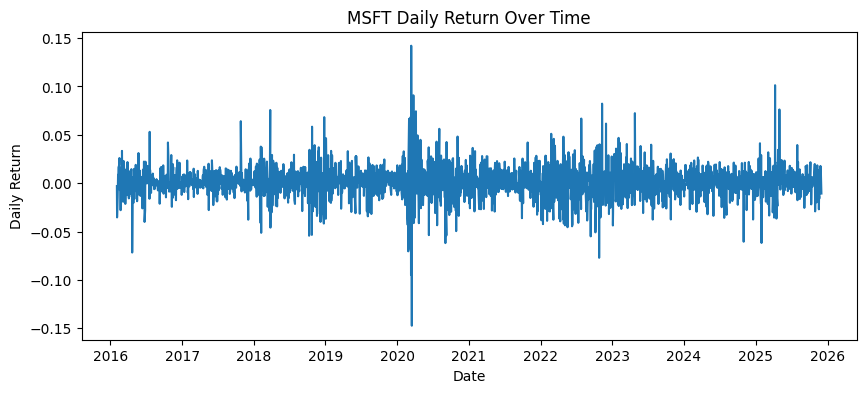

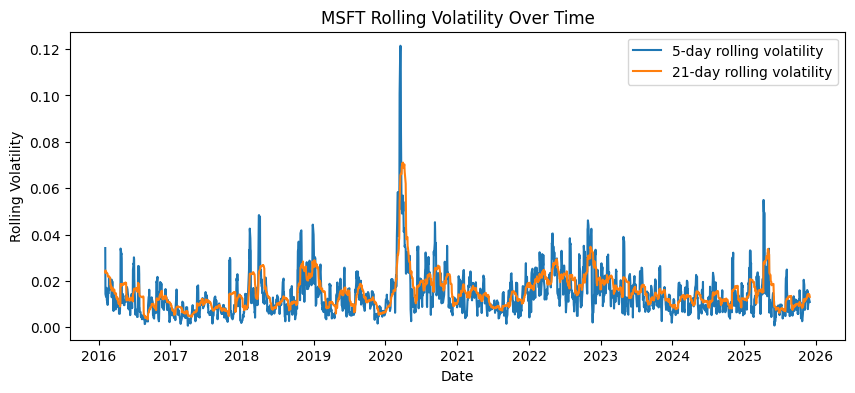

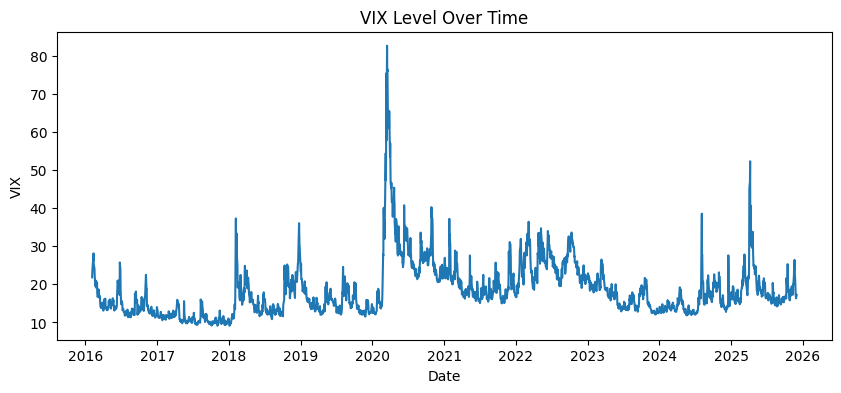

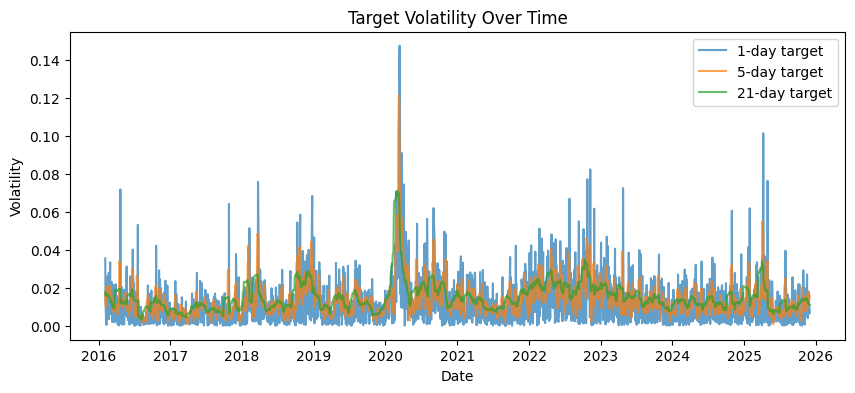

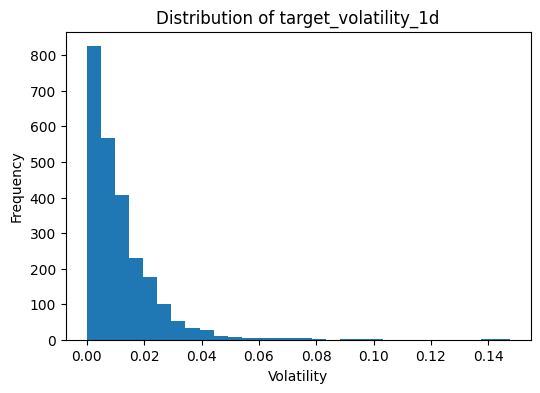

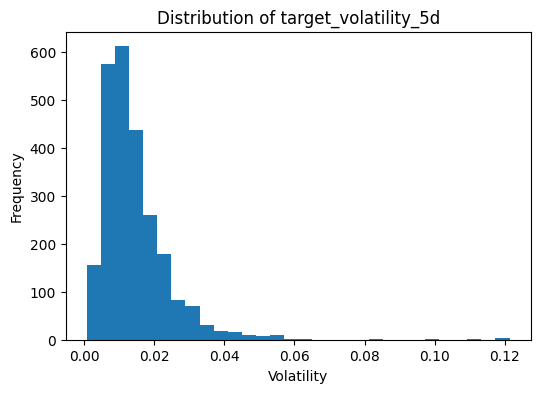

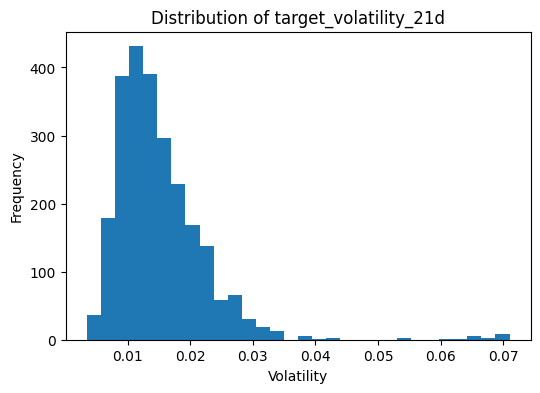

In [9]:
# Example visualization
# plt.figure(figsize=(6,4))
# df['your_column'].hist(bins=30)
# plt.title('Distribution of your_column')
# plt.show()

# =========================
# 3.2 MSFT daily return over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_return_1d'])
plt.title('MSFT Daily Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()

# =========================
# 3.3 MSFT rolling volatility
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['MSFT_rolling_vol_5'], label='5-day rolling volatility')
plt.plot(model_data.index, model_data['MSFT_rolling_vol_21'], label='21-day rolling volatility')
plt.title('MSFT Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Rolling Volatility')
plt.legend()
plt.show()

# =========================
# 3.4 VIX level over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['VIX_level'])
plt.title('VIX Level Over Time')
plt.xlabel('Date')
plt.ylabel('VIX')
plt.show()

# =========================
# 3.5 Target variable summary
# =========================

target_cols = [
    'target_volatility_1d',
    'target_volatility_5d',
    'target_volatility_21d'
]

model_data[target_cols].describe()

# =========================
# 3.6 Target volatility over time
# =========================

plt.figure(figsize=(10, 4))
plt.plot(model_data.index, model_data['target_volatility_1d'], label='1-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_5d'], label='5-day target', alpha=0.7)
plt.plot(model_data.index, model_data['target_volatility_21d'], label='21-day target', alpha=0.7)
plt.title('Target Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

# =========================
# 3.7 Distribution of target variables
# =========================

for col in target_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(model_data[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Volatility')
    plt.ylabel('Frequency')
    plt.show()

# 4. Methodology

Clearly separate the problem description from the learning algorithms.

Include a separate subsection for hyperparameter tuning:
- Explain how tuning is performed.
- Make the comparison fair across models.
- State the validation procedure clearly.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.


## 4.2 Model 1: ___

**Implemented by: Jenny Fu** 

- Motivation
- Model description
- Why this method is appropriate/Key assumptions


## 4.3 Model 2: Gradient Boost

**Implemented by: Emma Xu** 

- Motivation

    Gradient Boosting is used because stock volatility is likely driven by nonlinear relationships among market variables. For example, the effect of VIX on MSFT volatility may become stronger during high-volatility periods, and recent MSFT volatility may interact with market-wide volatility measures such as SPY and XLK rolling volatility. A simple linear model may not fully capture these nonlinear patterns.

- Model description

    Gradient Boosting is an ensemble learning method that builds many decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees. Instead of fitting one large tree, the model combines many small trees to gradually improve prediction accuracy.

- Why this method is appropriate

    This method is appropriate for volatility prediction because financial volatility often has nonlinear behavior, volatility clustering, and interactions between stock-specific and market-wide variables. Gradient Boosting can capture these complex patterns without requiring us to manually specify nonlinear terms.


Repeat until Model N (N=your group size)

Best Gradient Boosting validation performance:


,Horizon,n_estimators,learning_rate,max_depth,Validation MAE,Validation RMSE,Validation Normalized MAE,Validation R2
0,Daily 1D,300,0.05,2,0.006857,0.009158,0.605254,0.103581
1,Weekly 5D,200,0.01,2,0.004428,0.005896,0.320110,0.089784
2,Monthly 21D,200,0.03,2,0.002317,0.002969,0.162219,0.289289


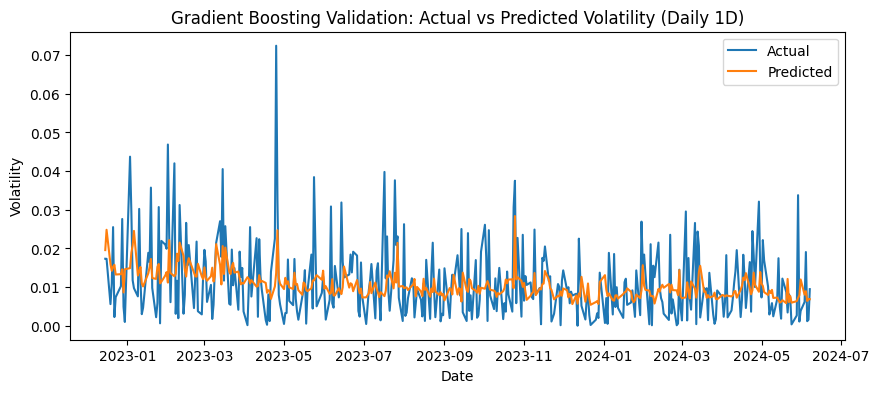

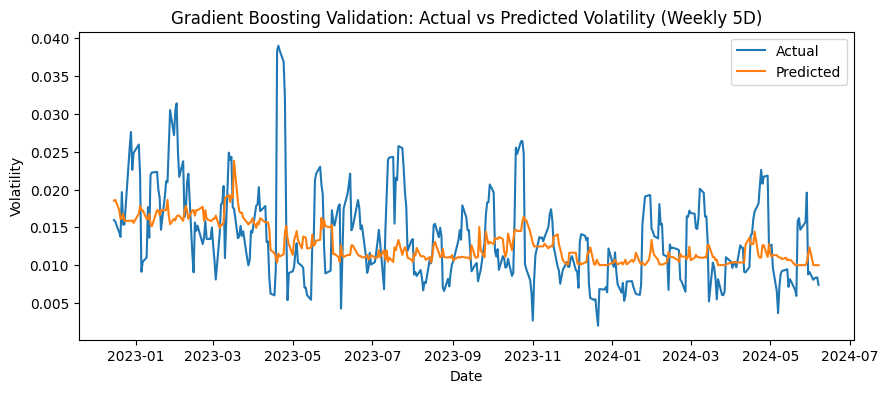

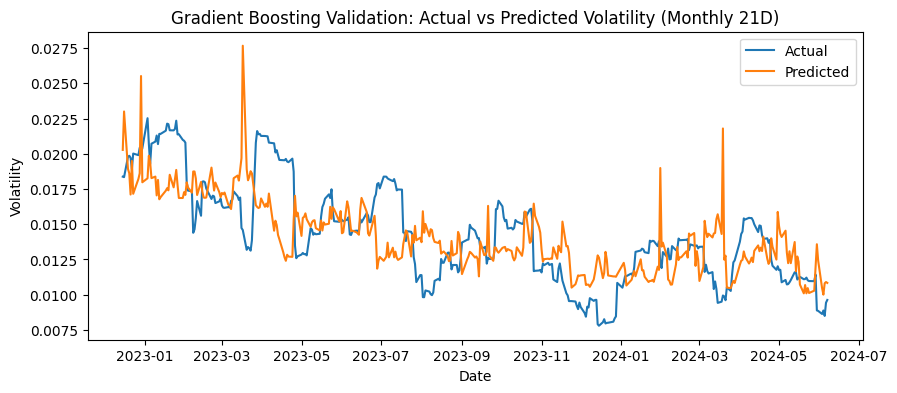

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

# Targets for validation tuning
targets = {
    'Daily 1D': (y_train_1d, y_valid_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d)
}

# Candidate hyperparameters
param_grid = [
    {'n_estimators': 50, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2},
]

tuning_results = []

for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    
    for params in param_grid:
        
        model = GradientBoostingRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            random_state=42
        )
        
        # Train on training set only
        model.fit(X_train_scaled, y_train)
        
        # Predict on validation set only
        y_valid_pred = model.predict(X_valid_scaled)
        
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_mae = valid_mae / y_valid.mean()
        
        tuning_results.append({
            'Horizon': horizon,
            'n_estimators': params['n_estimators'],
            'learning_rate': params['learning_rate'],
            'max_depth': params['max_depth'],
            'Validation MAE': valid_mae,
            'Validation RMSE': valid_rmse,
            'Validation Normalized MAE': valid_normalized_mae,
            'Validation R2': valid_r2
        })

tuning_results_df = pd.DataFrame(tuning_results)

# Sort full tuning table by horizon and normalized MAE
tuning_results_df['Horizon'] = pd.Categorical(
    tuning_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

tuning_results_df = (
    tuning_results_df
    .sort_values(['Horizon', 'Validation Normalized MAE'])
    .reset_index(drop=True)
)

tuning_results_df

# Select best parameters for each horizon
best_params_by_horizon = (
    tuning_results_df
    .sort_values('Validation Normalized MAE')
    .groupby('Horizon', observed=True)
    .first()
    .reset_index()
)

best_params_by_horizon['Horizon'] = pd.Categorical(
    best_params_by_horizon['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_params_by_horizon = (
    best_params_by_horizon
    .sort_values('Horizon')
    .reset_index(drop=True)
)


# Refit best Gradient Boosting models and plot validation predictions
best_gb_models = {}
best_gb_valid_predictions = {}
best_gb_valid_results = []

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    y_train, y_valid = targets[horizon]
    
    model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    # Train on training set only
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_valid_pred = model.predict(X_valid_scaled)
    
    # Validation metrics
    valid_mae = mean_absolute_error(y_valid, y_valid_pred)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
    valid_r2 = r2_score(y_valid, y_valid_pred)
    valid_normalized_mae = valid_mae / y_valid.mean()
    
    best_gb_valid_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Validation MAE': valid_mae,
        'Validation RMSE': valid_rmse,
        'Validation Normalized MAE': valid_normalized_mae,
        'Validation R2': valid_r2
    })
    
    best_gb_models[horizon] = model
    best_gb_valid_predictions[horizon] = y_valid_pred

best_gb_valid_results_df = pd.DataFrame(best_gb_valid_results)

best_gb_valid_results_df['Horizon'] = pd.Categorical(
    best_gb_valid_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

best_gb_valid_results_df = (
    best_gb_valid_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Best Gradient Boosting validation performance:")
display(best_gb_valid_results_df)

# Validation actual vs predicted plots using best models
for horizon in horizon_order:
    
    y_train, y_valid = targets[horizon]
    y_valid_pred = best_gb_valid_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_valid.index, y_valid, label='Actual')
    plt.plot(y_valid.index, y_valid_pred, label='Predicted')
    plt.title(f'Gradient Boosting Validation: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

Top 10 Feature Importances for Daily 1D:


,Feature,Importance
16,VIX_level,0.210481
9,MSFT_log_volume,0.170326
7,MSFT_rolling_vol_5,0.083427
10,SPY_return_1d,0.071793
4,MSFT_return_lag10,0.068415
18,VIX_lag1,0.042796
23,MSFT_minus_SPY_return,0.035065
11,SPY_return_lag1,0.034760
13,SPY_rolling_vol_21,0.034496
14,QQQ_return_1d,0.034049


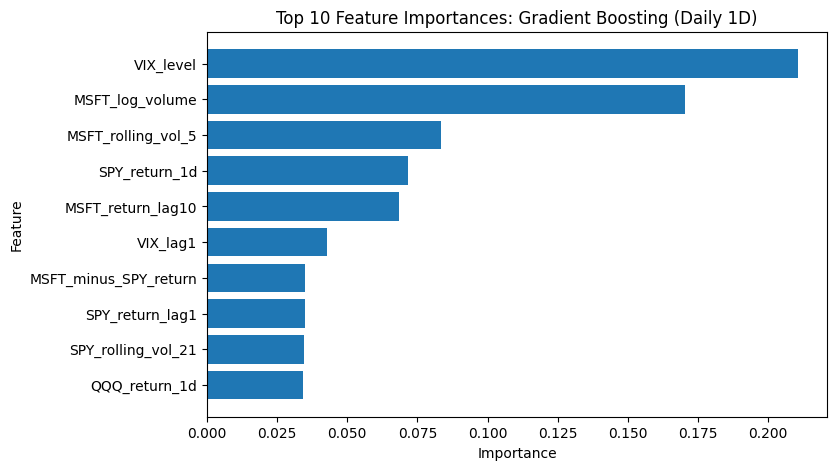

Top 10 Feature Importances for Weekly 5D:


,Feature,Importance
16,VIX_level,0.387821
20,XLK_rolling_vol_5,0.215618
12,SPY_rolling_vol_5,0.110073
9,MSFT_log_volume,0.075518
13,SPY_rolling_vol_21,0.060323
8,MSFT_rolling_vol_21,0.047650
15,QQQ_rolling_vol_21,0.037728
21,XLK_rolling_vol_21,0.021439
14,QQQ_return_1d,0.020302
11,SPY_return_lag1,0.007689


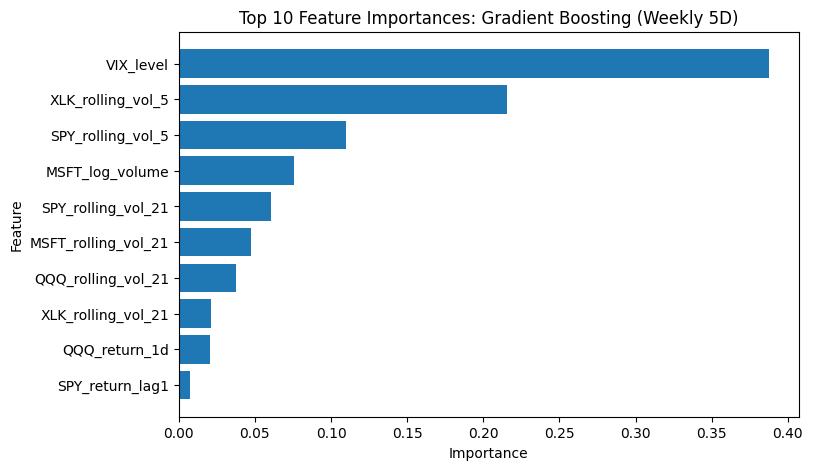

Top 10 Feature Importances for Monthly 21D:


,Feature,Importance
16,VIX_level,0.229571
8,MSFT_rolling_vol_21,0.176463
20,XLK_rolling_vol_5,0.123561
21,XLK_rolling_vol_21,0.120434
9,MSFT_log_volume,0.097424
15,QQQ_rolling_vol_21,0.065184
12,SPY_rolling_vol_5,0.036654
17,VIX_change,0.030229
13,SPY_rolling_vol_21,0.026208
11,SPY_return_lag1,0.020755


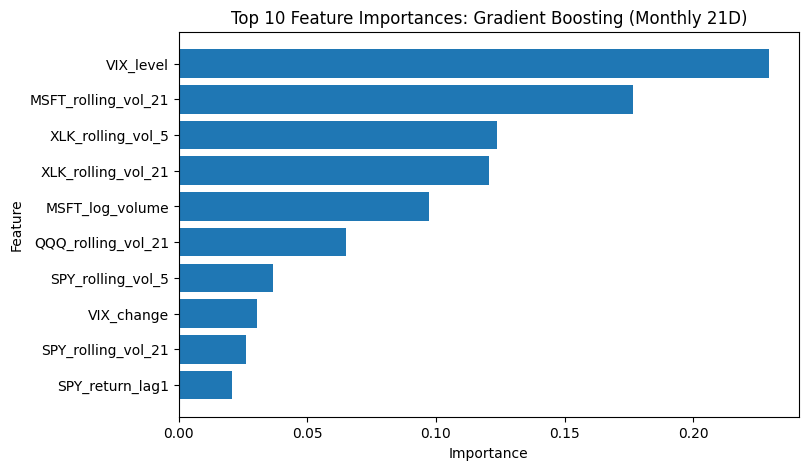

In [ ]:
# Feature Importance for Best Gradient Boosting Models
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_dfs = {}

for horizon in horizon_order:
    
    model = best_gb_models[horizon]
    
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    feature_importance_dfs[horizon] = importance_df
    
    print(f"Top 10 Feature Importances for {horizon}:")
    display(importance_df.head(10))
    
    plt.figure(figsize=(8, 5))
    plt.barh(
        importance_df.head(10)['Feature'][::-1],
        importance_df.head(10)['Importance'][::-1]
    )
    plt.title(f'Top 10 Feature Importances: Gradient Boosting ({horizon})')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

Final Gradient Boosting Test Performance:


,Horizon,n_estimators,learning_rate,max_depth,Test MAE,Test RMSE,Test Normalized MAE,Test R2
0,Daily 1D,300,0.05,2,0.007477,0.010790,0.750926,-0.028425
1,Weekly 5D,200,0.01,2,0.005644,0.007941,0.451757,-0.068448
2,Monthly 21D,200,0.03,2,0.004313,0.005741,0.315305,-0.181445


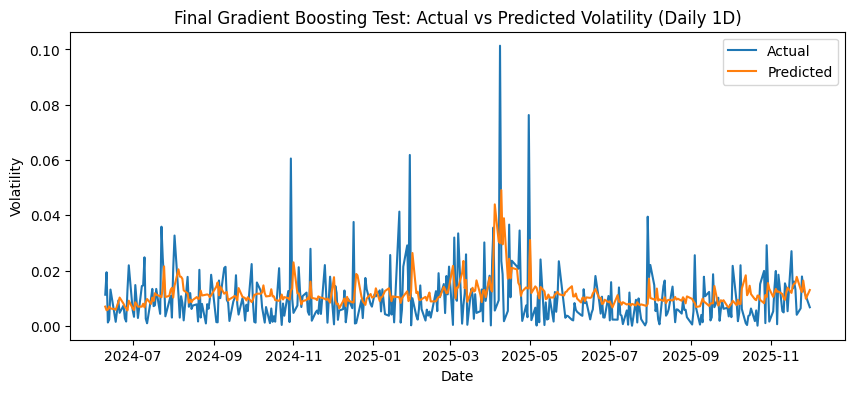

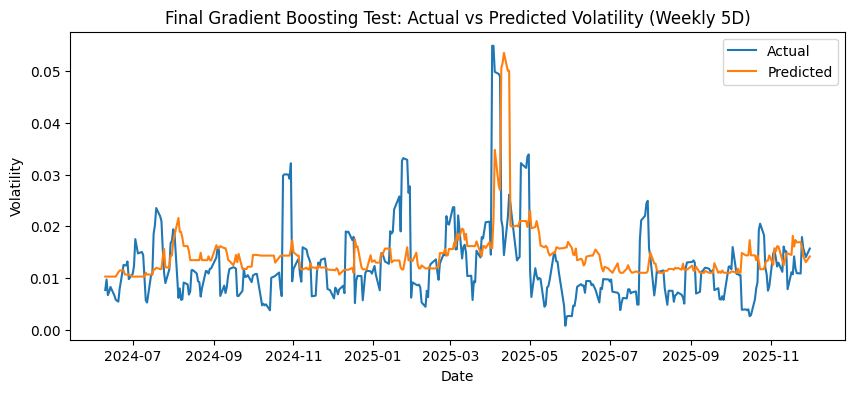

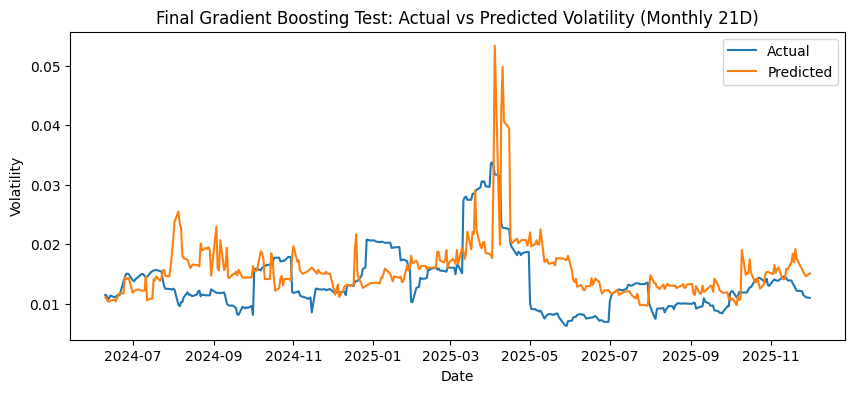

In [20]:

# Final Test Evaluation using Best Validation Parameters
from IPython.display import display

# Horizon order
horizon_order = ['Daily 1D', 'Weekly 5D', 'Monthly 21D']

targets_full = {
    'Daily 1D': (y_train_1d, y_valid_1d, y_test_1d),
    'Weekly 5D': (y_train_5d, y_valid_5d, y_test_5d),
    'Monthly 21D': (y_train_21d, y_valid_21d, y_test_21d)
}

# Combine train + validation features
X_train_valid = pd.concat([X_train, X_valid])

final_scaler = StandardScaler()

X_train_valid_scaled = final_scaler.fit_transform(X_train_valid)
X_test_scaled_final = final_scaler.transform(X_test)

X_train_valid_scaled = pd.DataFrame(
    X_train_valid_scaled,
    index=X_train_valid.index,
    columns=feature_cols
)

X_test_scaled_final = pd.DataFrame(
    X_test_scaled_final,
    index=X_test.index,
    columns=feature_cols
)


# Final model training and test evaluation
final_test_results = []
final_gb_models = {}
final_gb_test_predictions = {}

for _, row in best_params_by_horizon.iterrows():
    
    horizon = row['Horizon']
    
    y_train, y_valid, y_test = targets_full[horizon]
    
    y_train_valid = pd.concat([y_train, y_valid])
    
    final_model = GradientBoostingRegressor(
        n_estimators=int(row['n_estimators']),
        learning_rate=float(row['learning_rate']),
        max_depth=int(row['max_depth']),
        random_state=42
    )
    
    final_model.fit(X_train_valid_scaled, y_train_valid)
    
    # Predict on test set only
    y_test_pred = final_model.predict(X_test_scaled_final)
    
    # Test metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_normalized_mae = test_mae / y_test.mean()
    
    final_test_results.append({
        'Horizon': horizon,
        'n_estimators': int(row['n_estimators']),
        'learning_rate': float(row['learning_rate']),
        'max_depth': int(row['max_depth']),
        'Test MAE': test_mae,
        'Test RMSE': test_rmse,
        'Test Normalized MAE': test_normalized_mae,
        'Test R2': test_r2
    })
    
    final_gb_models[horizon] = final_model
    final_gb_test_predictions[horizon] = y_test_pred


# Create final test results DataFrame
final_test_results_df = pd.DataFrame(final_test_results)

final_test_results_df['Horizon'] = pd.Categorical(
    final_test_results_df['Horizon'],
    categories=horizon_order,
    ordered=True
)

final_test_results_df = (
    final_test_results_df
    .sort_values('Horizon')
    .reset_index(drop=True)
)

print("Final Gradient Boosting Test Performance:")
display(final_test_results_df)


# Test Actual vs Predicted Plots
for horizon in horizon_order:
    
    _, _, y_test = targets_full[horizon]
    y_test_pred = final_gb_test_predictions[horizon]
    
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, y_test_pred, label='Predicted')
    plt.title(f'Final Gradient Boosting Test: Actual vs Predicted Volatility ({horizon})')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

## 4.4 Model 3: ___

**Implemented by: Shawn Wen** 

- Motivation
- Model description
- Why this method is appropriate


Repeat until Model N (N=your group size)


## 4.5 Model 4: ___

**Implemented by: Summer Zhu** 

- Motivation
- Model description
- Why this method is appropriate


Repeat until Model N (N=your group size)


# 5. Results

Clearly separate the presentation of results from the conclusions.

## 5.1 Evaluation Metrics
- Explain why the chosen metrics are appropriate.

## 5.2 Main Quantitative Results
- Present results in tables. Compare model performance after tuning.


## 5.3 Visualizations
- Prediction vs actual
- Residual plots
- Feature importance
- Confusion matrix or ROC curve if classification


# 6. Discussions and Conclusions

Make it brief; (2-3 paragraphs max)

Discuss:
- Which model performed best?
- Why do you think it performed best?
- What do the results mean in the financial context?
- Are there economic or practical implications?
- What are the limitations of the study?

Conclude:
- Summarize the main findings.
- State the major takeaway.
- Suggest possible future work.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [10]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

- Include all papers, datasets, websites, and software packages cited in the notebook.
- Use a consistent citation style.
